# NYC Taxi Spark EDA

This notebook performs Exploratory Data Analysis using PySpark on a large NYC taxi dataset.

Goals:
- Inspect dataset structure
- Perform data quality checks
- Engineer temporal features
- Analyze demand patterns
- Detect anomalies
- Inspect Spark execution plans


## 1. Initialize Spark

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName('spark-taxi-eda')
    .master('local[*]')
    .config('spark.sql.shuffle.partitions', 200)
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')

spark

## 2. Load Dataset

In [2]:
import glob
from tqdm import tqdm

files = glob.glob("../data/raw/*.parquet")

print("Number of files:", len(files))

dfs = []

for file in tqdm(files):
    try:
        temp_df = spark.read.parquet(file)
        dfs.append(temp_df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

df = dfs[0]

for d in dfs[1:]:
    df = df.unionByName(d)

Number of files: 12


100%|██████████| 12/12 [00:02<00:00,  4.30it/s]


## 3. Dataset Overview

In [3]:
import os

size_bytes = sum(os.path.getsize(f) for f in files)
size_gb = size_bytes / (1024**3)

print('Columns:', len(df.columns))
print('Rows:', df.count())
print('Partitions:', df.rdd.getNumPartitions())
print(f"Dataset size: {size_gb:.2f} GB")

Columns: 25
Rows: 243589684
Partitions: 192
Dataset size: 5.55 GB


In [4]:
df.printSchema()

root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- on_scene_datetime: timestamp_ntz (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: string (nullable = true)
 |-- access_a_

## 4. Missing Values

In [5]:
from pyspark.sql.functions import col, count, when

missing = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing.show()

+-----------------+--------------------+--------------------+----------------+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+-----+---+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+------------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|request_datetime|on_scene_datetime|pickup_datetime|dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls|bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|cbd_congestion_fee|
+-----------------+--------------------+--------------------+----------------+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+-----+---+---------+--------------------+-----------+---

## 5. Feature Engineering

In [6]:
from pyspark.sql.functions import hour, dayofweek, month, to_date

df = (
    df
    .withColumn('pickup_hour', hour('pickup_datetime'))
    .withColumn('pickup_dayofweek', dayofweek('pickup_datetime'))
    .withColumn('pickup_month', month('pickup_datetime'))
    .withColumn('pickup_date', to_date('pickup_datetime'))
)

df.select('pickup_datetime','pickup_hour','pickup_dayofweek','pickup_month').show(5)

+-------------------+-----------+----------------+------------+
|    pickup_datetime|pickup_hour|pickup_dayofweek|pickup_month|
+-------------------+-----------+----------------+------------+
|2025-01-01 00:33:25|          0|               4|           1|
|2025-01-01 00:29:49|          0|               4|           1|
|2025-01-01 00:32:39|          0|               4|           1|
|2025-01-01 00:34:55|          0|               4|           1|
|2025-01-01 00:46:19|          0|               4|           1|
+-------------------+-----------+----------------+------------+
only showing top 5 rows


## 6. Hourly Demand

In [7]:
hourly_demand = (
    df.groupBy('pickup_hour')
    .count()
    .orderBy('pickup_hour')
)

hourly_demand.show()

+-----------+--------+
|pickup_hour|   count|
+-----------+--------+
|          0| 8713817|
|          1| 6098806|
|          2| 4367605|
|          3| 3540262|
|          4| 3743159|
|          5| 4446709|
|          6| 6849001|
|          7|10195110|
|          8|12493922|
|          9|11660740|
|         10|10690156|
|         11|10470268|
|         12|10673947|
|         13|11046102|
|         14|11913408|
|         15|12198935|
|         16|12608961|
|         17|13816750|
|         18|14281332|
|         19|13828504|
+-----------+--------+
only showing top 20 rows


### Visualization

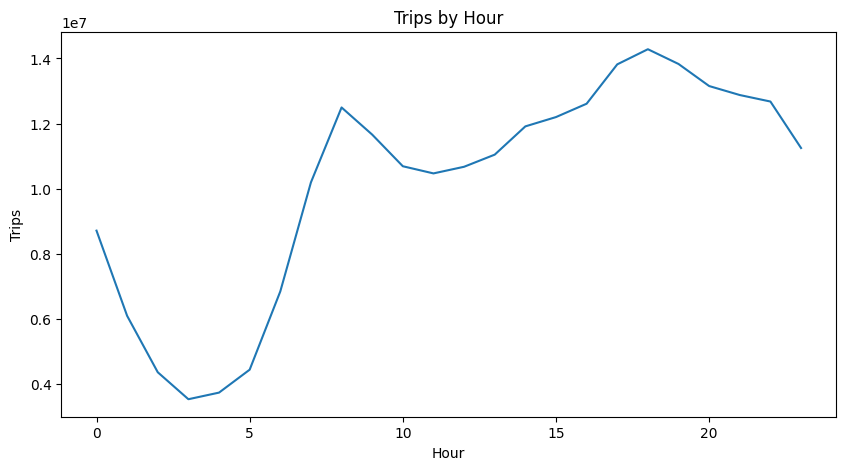

In [8]:
import matplotlib.pyplot as plt

hourly_pd = hourly_demand.toPandas()

plt.figure(figsize=(10,5))
plt.plot(hourly_pd['pickup_hour'], hourly_pd['count'])
plt.title('Trips by Hour')
plt.xlabel('Hour')
plt.ylabel('Trips')
plt.show()

## 7. Top Pickup Locations

In [9]:
from pyspark.sql.functions import desc

top_locations = (
    df.groupBy('PULocationID')
    .count()
    .orderBy(desc('count'))
)

top_locations.show(20)

+------------+-------+
|PULocationID|  count|
+------------+-------+
|         138|4923107|
|         132|4068926|
|          61|3165225|
|         230|2898426|
|          79|2897628|
|         161|2820283|
|          76|2718688|
|          37|2691982|
|         231|2651787|
|          68|2537812|
|         234|2527548|
|         246|2506681|
|         255|2443559|
|         164|2424528|
|         148|2412641|
|         112|2401659|
|         181|2353365|
|           7|2334965|
|          48|2296013|
|          42|2158453|
+------------+-------+
only showing top 20 rows


## 8. Trip Distance Distribution

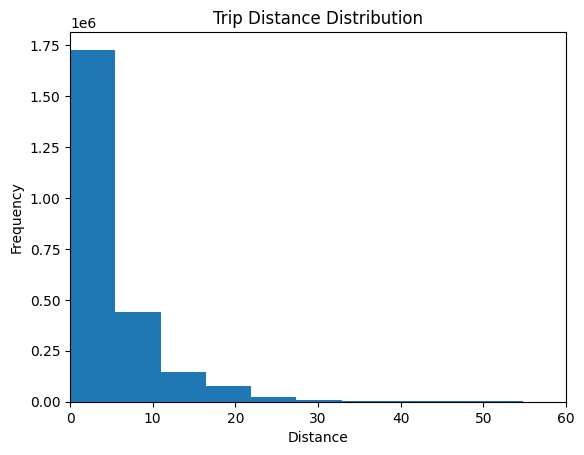

In [20]:
distance_sample = df.select('trip_miles').sample(0.01).toPandas()

plt.hist(distance_sample['trip_miles'], bins=50)
plt.title('Trip Distance Distribution')
plt.xlim(0, 60)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.show()

## 9. Trip Volume by Company

In [18]:
df   \
    .groupBy("hvfhs_license_num") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

+-----------------+---------+
|hvfhs_license_num|    count|
+-----------------+---------+
|           HV0003|175989546|
|           HV0005| 67600138|
+-----------------+---------+



## 10. Fare vs Distance Relationship

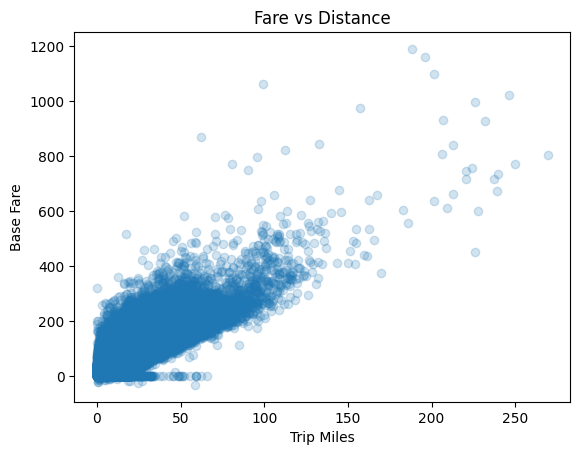

In [19]:
sample = df.select("trip_miles","base_passenger_fare").sample(0.01).toPandas()

import matplotlib.pyplot as plt

plt.scatter(sample["trip_miles"], sample["base_passenger_fare"], alpha=0.2)
plt.xlabel("Trip Miles")
plt.ylabel("Base Fare")
plt.title("Fare vs Distance")
plt.show()

## 11. Detect Anomalous Trips (Speed)

In [11]:
from pyspark.sql.functions import col, expr

df = df.withColumn(
    "speed_mph",
    expr("try_divide(trip_miles, trip_time/3600)")
)

df.filter((col("trip_time") > 0) & (col("speed_mph") > 200)).show()

+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+-----+----------+-------------------+-----------------+------------------+----------------+--------------+------------------+-----------+----------------+------------+-----------+------------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|   request_datetime|  on_scene_datetime|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls| bcf|sales_tax|congestion_surcharge|airport_fee| tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|cbd_congestion_fee|pickup_hour|pickup_dayofweek|pickup_month|pickup_date|         speed_mph|
+-----------------+--------------------+--------------------+-----------------

## 12. Window Function Example – Longest Trips per Day

In [12]:
from pyspark.sql.functions import to_date, col
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

df = df.withColumn("pickup_date", to_date("pickup_datetime"))

window_spec = Window.partitionBy("pickup_date").orderBy(col("trip_miles").desc())

ranked = df.withColumn("rank", row_number().over(window_spec))

ranked.filter("rank <= 5").show()

+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+-----+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+------------------+-----------+----------------+------------+-----------+------------------+----+
|hvfhs_license_num|dispatching_base_num|originating_base_num|   request_datetime|  on_scene_datetime|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls|  bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|cbd_congestion_fee|pickup_hour|pickup_dayofweek|pickup_month|pickup_date|         speed_mph|rank|
+-----------------+--------------------+--------------------+-------

## 13. Correlation Analysis

In [13]:
df.stat.corr("trip_miles","base_passenger_fare")

0.8475858670403232

## 14. Busiest pickup locations

In [14]:
from pyspark.sql.functions import col, count

top_locations = (
    df
        .groupBy("PULocationID")
        .agg(count("*")
        .alias("trip_count"))
        .orderBy(col("trip_count")
        .desc())
)

top_locations.show(20)

+------------+----------+
|PULocationID|trip_count|
+------------+----------+
|         138|   4923107|
|         132|   4068926|
|          61|   3165225|
|         230|   2898426|
|          79|   2897628|
|         161|   2820283|
|          76|   2718688|
|          37|   2691982|
|         231|   2651787|
|          68|   2537812|
|         234|   2527548|
|         246|   2506681|
|         255|   2443559|
|         164|   2424528|
|         148|   2412641|
|         112|   2401659|
|         181|   2353365|
|           7|   2334965|
|          48|   2296013|
|          42|   2158453|
+------------+----------+
only showing top 20 rows


## 15. Execution plan analysis

In [15]:
top_locations.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [trip_count#1495L DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(trip_count#1495L DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=2150]
      +- HashAggregate(keys=[PULocationID#7], functions=[count(1)])
         +- Exchange hashpartitioning(PULocationID#7, 200), ENSURE_REQUIREMENTS, [plan_id=2147]
            +- HashAggregate(keys=[PULocationID#7], functions=[partial_count(1)])
               +- Union
                  :- FileScan parquet [PULocationID#7] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/c:/Users/papai/OneDrive/Desktop/spark-medallion-pipeline/data/ra..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<PULocationID:int>
                  :- FileScan parquet [PULocationID#32] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/c:/Users/papai/OneDrive/Desktop/spark-medallion-pipeline/data/ra..., Pa

In [16]:
df.explain("formatted")

== Physical Plan ==
Union (37)
:- * Project (3)
:  +- * ColumnarToRow (2)
:     +- Scan parquet  (1)
:- * Project (6)
:  +- * ColumnarToRow (5)
:     +- Scan parquet  (4)
:- * Project (9)
:  +- * ColumnarToRow (8)
:     +- Scan parquet  (7)
:- * Project (12)
:  +- * ColumnarToRow (11)
:     +- Scan parquet  (10)
:- * Project (15)
:  +- * ColumnarToRow (14)
:     +- Scan parquet  (13)
:- * Project (18)
:  +- * ColumnarToRow (17)
:     +- Scan parquet  (16)
:- * Project (21)
:  +- * ColumnarToRow (20)
:     +- Scan parquet  (19)
:- * Project (24)
:  +- * ColumnarToRow (23)
:     +- Scan parquet  (22)
:- * Project (27)
:  +- * ColumnarToRow (26)
:     +- Scan parquet  (25)
:- * Project (30)
:  +- * ColumnarToRow (29)
:     +- Scan parquet  (28)
:- * Project (33)
:  +- * ColumnarToRow (32)
:     +- Scan parquet  (31)
+- * Project (36)
   +- * ColumnarToRow (35)
      +- Scan parquet  (34)


(1) Scan parquet 
Output [25]: [hvfhs_license_num#0, dispatching_base_num#1, originating_base_num#2,

In [17]:
hourly_demand.explain('formatted')

== Physical Plan ==
AdaptiveSparkPlan (66)
+- == Final Plan ==
   ResultQueryStage (47)
   +- * Sort (46)
      +- AQEShuffleRead (45)
         +- ShuffleQueryStage (44), Statistics(sizeInBytes=576.0 B, rowCount=24)
            +- Exchange (43)
               +- * HashAggregate (42)
                  +- AQEShuffleRead (41)
                     +- ShuffleQueryStage (40), Statistics(sizeInBytes=107.9 KiB, rowCount=4.61E+3)
                        +- Exchange (39)
                           +- * HashAggregate (38)
                              +- Union (37)
                                 :- * Project (3)
                                 :  +- * ColumnarToRow (2)
                                 :     +- Scan parquet  (1)
                                 :- * Project (6)
                                 :  +- * ColumnarToRow (5)
                                 :     +- Scan parquet  (4)
                                 :- * Project (9)
                                 :  +- * ColumnarTo